In [1]:
#Import Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:/Training/bmi.csv")
df.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [3]:
#Dataset Basic Information
print("Shape of dataset:", df.shape)
print("\nColumn names:", df.columns)
print("\nData types:\n", df.dtypes)

Shape of dataset: (500, 4)

Column names: Index(['Gender', 'Height', 'Weight', 'Index'], dtype='object')

Data types:
 Gender    object
Height     int64
Weight     int64
Index      int64
dtype: object


In [4]:
#Detailed Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [5]:
#Statistical Summary
df.describe()

,Height,Weight,Index
count,500.000000,500.000000,500.000000
mean,169.944000,106.000000,3.748000
std,16.375261,32.382607,1.355053
min,140.000000,50.000000,0.000000
25%,156.000000,80.000000,3.000000
50%,170.500000,106.000000,4.000000
75%,184.000000,136.000000,5.000000
max,199.000000,160.000000,5.000000


In [6]:
#Check Missing Values
df.isnull().sum()

Gender    0
Height    0
Weight    0
Index     0
dtype: int64

In [7]:
#Duplicate values check and removal
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 11
Shape after removing duplicates: (489, 4)


In [8]:
#Separate Numerical & Categorical
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: Index(['Height', 'Weight', 'Index'], dtype='object')
Categorical: Index(['Gender'], dtype='object')


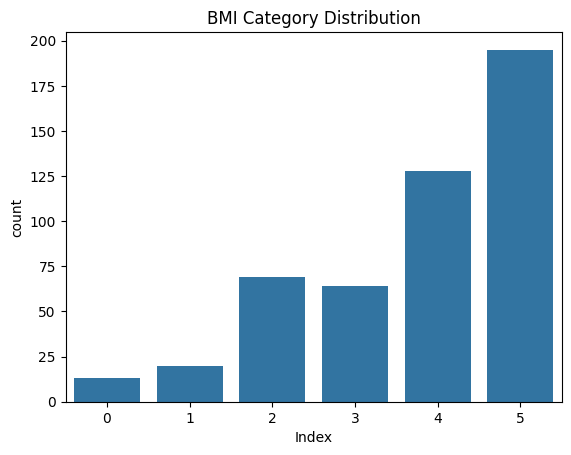

In [9]:
#Target Variable Distribution(Our target variable is Index)
sns.countplot(x="Index", data=df)
plt.title("BMI Category Distribution")
plt.show()

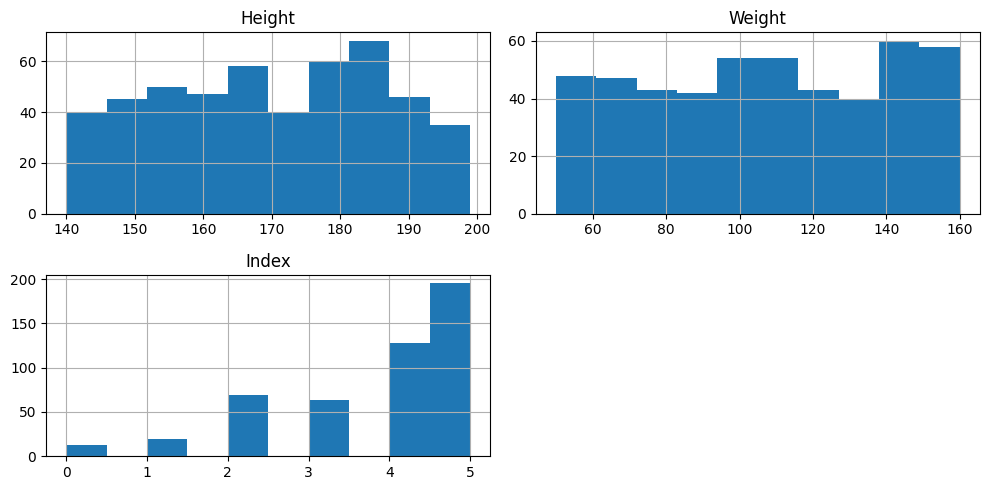

In [10]:
#Feature distribution
df[num_cols].hist(figsize=(10,5))
plt.tight_layout()
plt.show()

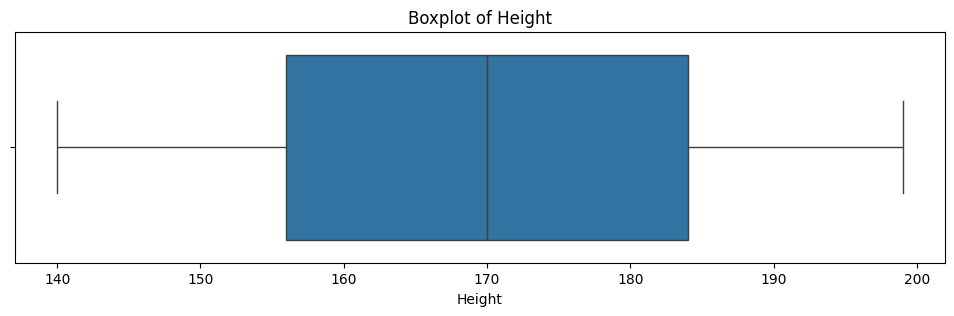

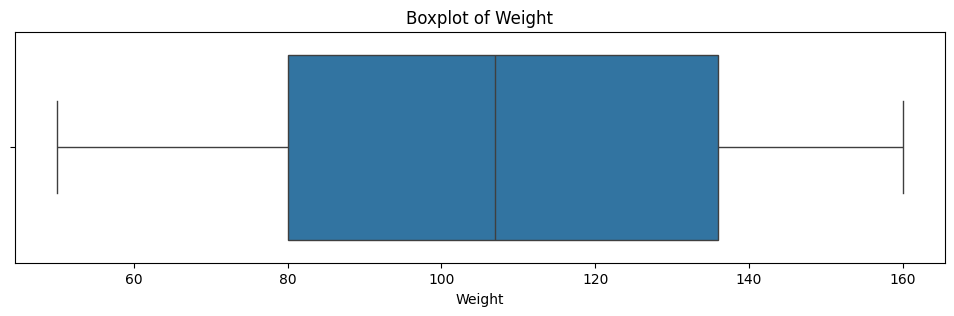

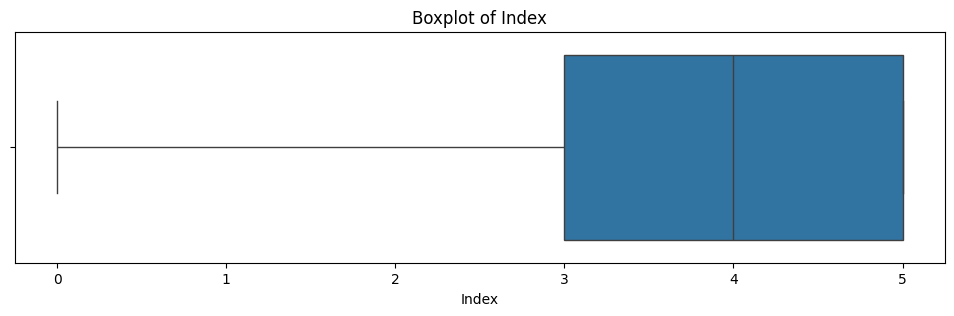

In [11]:
#Outlier Detection (Boxplots)
for col in num_cols:
    plt.figure(figsize=(12,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

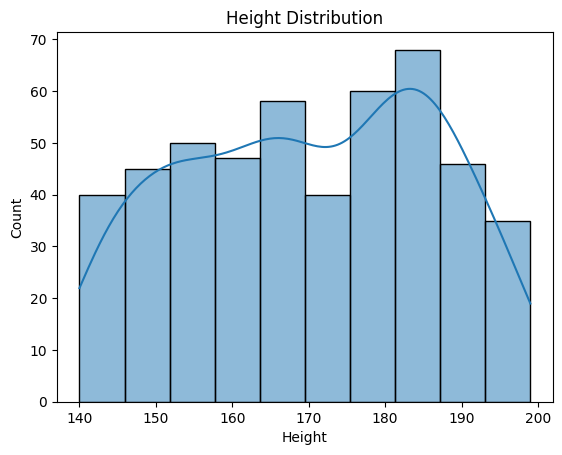

In [12]:
#Height Distribution
sns.histplot(df["Height"], kde=True)
plt.title("Height Distribution")
plt.show()

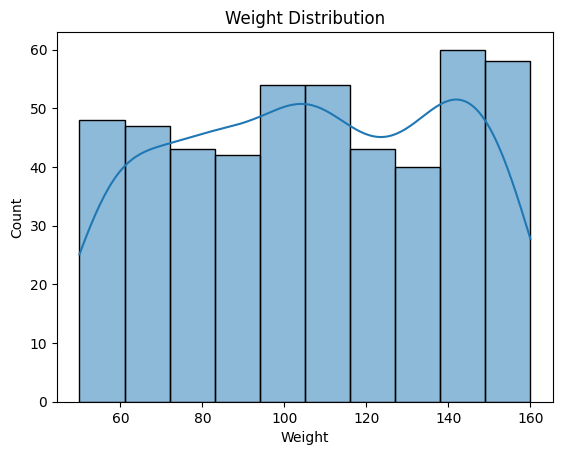

In [13]:
#Weight Distribution
sns.histplot(df["Weight"], kde=True)
plt.title("Weight Distribution")
plt.show()

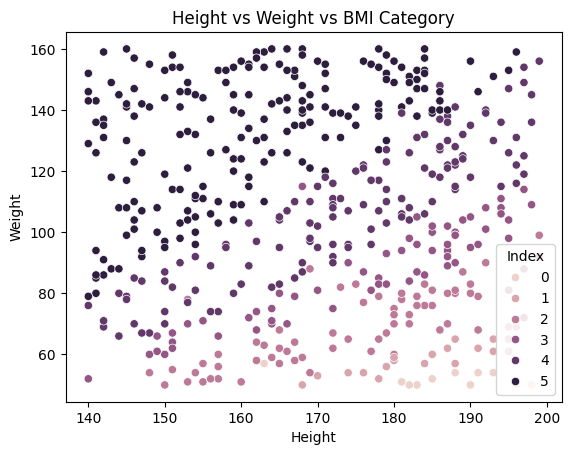

In [14]:
#Height vs Weight Relationship
sns.scatterplot(x="Height", y="Weight", hue="Index", data=df)
plt.title("Height vs Weight vs BMI Category")
plt.show()

In [15]:
#Separate Features and Target
x = df.drop('Index', axis=1)   # features
y = df['Index']                # target

In [16]:
x = pd.get_dummies(x, drop_first=True)
x = x.astype(int)
x.head()

,Height,Weight,Gender_Male
0,174,96,1
1,189,87,1
2,185,110,0
3,195,104,0
4,149,61,1


In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (391, 3)
Shape of x_test: (98, 3)
Shape of y_train: (391,)
Shape of y_test: (98,)


In [18]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train_scaled = sc.fit_transform(x_train)   # fit + transform train
x_test_scaled = sc.transform(x_test)         # only transform test

In [19]:
#Import models + accuracy tools
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [20]:
#Model Training + Prediction

In [21]:
#Decision Tree
dt = DecisionTreeClassifier()
dt.fit(x_train_scaled, y_train)

y_pred_dt = dt.predict(x_test_scaled)
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_dt, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_dt, average='weighted'))
print()

Decision Tree Performance
Accuracy : 0.8163265306122449
Precision: 0.8229013689843182
Recall   : 0.8163265306122449
F1 Score : 0.8164625850340136



In [22]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)

y_pred_lr = lr.predict(x_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_lr, average='weighted'))
print()

Logistic Regression Performance
Accuracy : 0.9081632653061225
Precision: 0.9013690804507131
Recall   : 0.9081632653061225
F1 Score : 0.892083600419466



C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [23]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)

y_pred_knn = knn.predict(x_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_knn, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_knn, average='weighted'))
print()

KNN Performance
Accuracy : 0.826530612244898
Precision: 0.8477374906825998
Recall   : 0.826530612244898
F1 Score : 0.8320685248254103



C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [24]:
nb = GaussianNB()
nb.fit(x_train_scaled, y_train)

y_pred_nb = nb.predict(x_test_scaled)
acc_nb = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_nb, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_nb, average='weighted'))
print()

Naive Bayes Performance
Accuracy : 0.7040816326530612
Precision: 0.7351565681705055
Recall   : 0.7040816326530612
F1 Score : 0.6971502379665645



#Confusion Matrix for all models

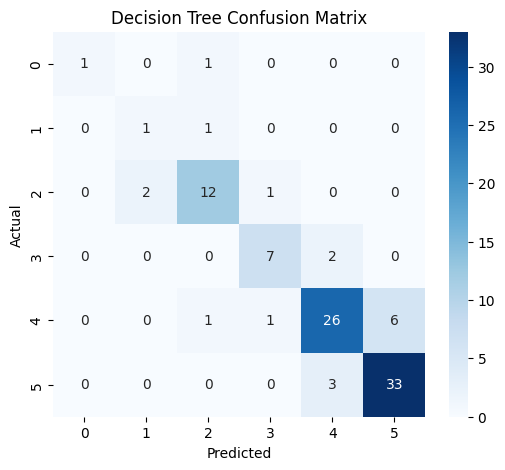

In [25]:
#Decision tree matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt='g', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

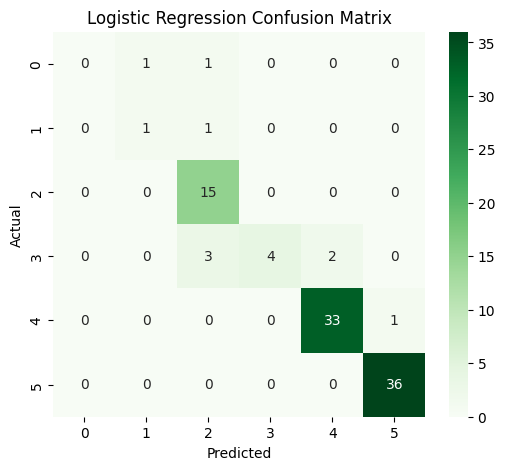

In [26]:
#Logistic regression confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='g', cmap='Greens')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

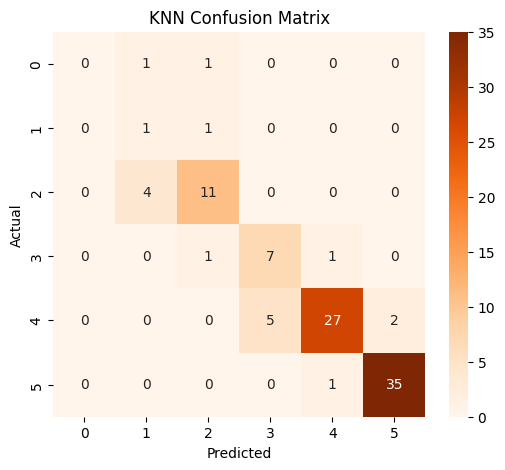

In [27]:
#KNN confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm_knn, annot=True, fmt='g', cmap='Oranges')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

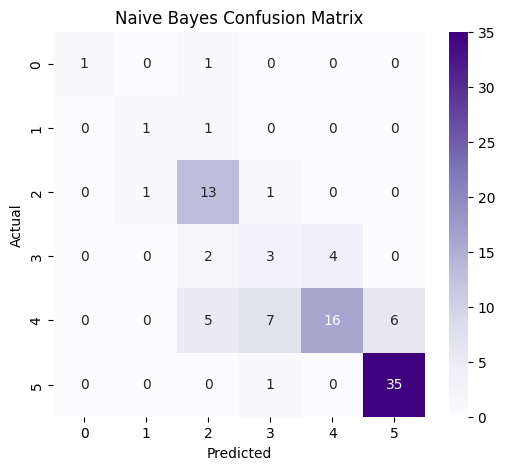

In [28]:
#Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='g', cmap='Purples')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
#Best model for this dataset
models = {
    "Decision Tree": dt,
    "Logistic Regression": lr,
    "KNN": knn,
    "Naive Bayes": nb
}

accuracies = {
    "Decision Tree": acc_dt,
    "Logistic Regression": acc_lr,
    "KNN": acc_knn,
    "Naive Bayes": acc_nb
}

best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Best Accuracy:", accuracies[best_model_name])

Best Model: Logistic Regression
Best Accuracy: 0.9081632653061225


In [30]:
x_scaled_full = sc.fit_transform(x)
best_model.fit(x_scaled_full, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
#Full comparision table
results_df = pd.DataFrame({
    "Model": ["Decision Tree", "Logistic Regression", "KNN", "Naive Bayes"],
    "Accuracy": [acc_dt, acc_lr, acc_knn, acc_nb],
    "Precision": [
        precision_score(y_test, y_pred_dt, average='weighted'),
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_knn, average='weighted'),
        precision_score(y_test, y_pred_nb, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt, average='weighted'),
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_knn, average='weighted'),
        recall_score(y_test, y_pred_nb, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted')
    ]
})

results_df

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.816327,0.822901,0.816327,0.816463
1,Logistic Regression,0.908163,0.901369,0.908163,0.892084
2,KNN,0.826531,0.847737,0.826531,0.832069
3,Naive Bayes,0.704082,0.735157,0.704082,0.697150


In [32]:
import pickle

# CHECK MODEL TRAINED OR NOT
try:
    sample = x.iloc[[0]]
    sample_scaled = sc.transform(sample)
    best_model.predict(sample_scaled)
    print("Model is trained ✅")
except:
    print("Train model first")

Model is trained ✅


In [33]:
# SAVE TRAINED MODEL
with open("bmi_model.pkl", "wb") as f:
    pickle.dump(best_model, f)


# SAVE SCALER
with open("scaler.pkl", "wb") as f:
    pickle.dump(sc, f)


# SAVE COLUMN ORDER (VERY IMPORTANT)
with open("columns.pkl", "wb") as f:
    pickle.dump(list(x.columns), f)


print("✅ Model, scaler and columns saved successfully")

✅ Model, scaler and columns saved successfully


In [34]:
print(type(best_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
